In [41]:
import pandas as pd
import os
import matplotlib.pyplot as plt 
import seaborn as sns


# Load the data (using raw string or forward slashes for Windows)
df = pd.read_csv(r'../data/raw/ethiopia_fi_unified_data.csv')
ref = pd.read_csv(r'../data/raw/reference_codes.csv')

print(" DATA LOADED SUCCESSFULLY!")
print(f"Total rows: {len(df)}")
print("\n--- COLUMN NAMES ---")
print(df.columns.tolist())

print("\n RECORD TYPE COUNTS ")
print(df['record_type'].value_counts())

print("\nFIRST EVENT EVER RECORDED ")
events = df[df['record_type'] == 'event']
print(events[['observation_date', 'category', 'indicator_code']].head())

print("\nDATE RANGE OF OBSERVATIONS ")
obs = df[df['record_type'] == 'observation']
print(f"Earliest: {obs['observation_date'].min()}")
print(f"Latest: {obs['observation_date'].max()}")

 DATA LOADED SUCCESSFULLY!
Total rows: 43

--- COLUMN NAMES ---
['record_id', 'record_type', 'category', 'pillar', 'indicator', 'indicator_code', 'indicator_direction', 'value_numeric', 'value_text', 'value_type', 'unit', 'observation_date', 'period_start', 'period_end', 'fiscal_year', 'gender', 'location', 'region', 'source_name', 'source_type', 'source_url', 'confidence', 'related_indicator', 'relationship_type', 'impact_direction', 'impact_magnitude', 'impact_estimate', 'lag_months', 'evidence_basis', 'comparable_country', 'collected_by', 'collection_date', 'original_text', 'notes']

 RECORD TYPE COUNTS 
record_type
observation    30
event          10
target          3
Name: count, dtype: int64

FIRST EVENT EVER RECORDED 
   observation_date        category indicator_code
33       2021-05-17  product_launch   EVT_TELEBIRR
34       2022-08-01    market_entry  EVT_SAFARICOM
35       2023-08-01  product_launch      EVT_MPESA
36       2024-01-01  infrastructure      EVT_FAYDA
37       2

In [42]:
df.columns

Index(['record_id', 'record_type', 'category', 'pillar', 'indicator',
       'indicator_code', 'indicator_direction', 'value_numeric', 'value_text',
       'value_type', 'unit', 'observation_date', 'period_start', 'period_end',
       'fiscal_year', 'gender', 'location', 'region', 'source_name',
       'source_type', 'source_url', 'confidence', 'related_indicator',
       'relationship_type', 'impact_direction', 'impact_magnitude',
       'impact_estimate', 'lag_months', 'evidence_basis', 'comparable_country',
       'collected_by', 'collection_date', 'original_text', 'notes'],
      dtype='str')

In [43]:
events = df[df['record_type'] == 'event']

events[['observation_date', 'category', 'indicator', 'source_name', 'notes']].head(10)

,observation_date,category,indicator,source_name,notes
33,2021-05-17,product_launch,Telebirr Launch,Ethio Telecom,NaN
34,2022-08-01,market_entry,Safaricom Ethiopia Commercial Launch,News,NaN
35,2023-08-01,product_launch,M-Pesa Ethiopia Launch,Safaricom,NaN
36,2024-01-01,infrastructure,Fayda Digital ID Program Rollout,NIDP,NaN
37,2024-07-29,policy,Foreign Exchange Liberalization,NBE,NaN
38,2024-10-01,milestone,P2P Transaction Count Surpasses ATM,EthSwitch,NaN
39,2025-10-27,partnership,M-Pesa EthSwitch Integration,EthSwitch,NaN
40,2025-12-18,infrastructure,EthioPay Instant Payment System Launch,NBE/EthSwitch,NaN
41,2021-09-01,policy,NFIS-II Strategy Launch,NBE,NaN
42,2025-12-15,pricing,Safaricom Ethiopia Price Increase,News,NaN


In [44]:
observations = df[df['record_type'] == 'observation']
observations[['observation_date', 'indicator', 'value_numeric', 'unit']]

,observation_date,indicator,value_numeric,unit
0,2014-12-31,Account Ownership Rate,2.200000e+01,%
1,2017-12-31,Account Ownership Rate,3.500000e+01,%
2,2021-12-31,Account Ownership Rate,4.600000e+01,%
3,2021-12-31,Account Ownership Rate,5.600000e+01,%
4,2021-12-31,Account Ownership Rate,3.600000e+01,%
5,2024-11-29,Account Ownership Rate,4.900000e+01,%
6,2021-12-31,Mobile Money Account Rate,4.700000e+00,%
7,2024-11-29,Mobile Money Account Rate,9.450000e+00,%
8,2023-06-30,4G Population Coverage,3.750000e+01,%
9,2025-06-30,4G Population Coverage,7.080000e+01,%


In [45]:
import os

os.makedirs('../data/processed', exist_ok=True)

df.to_csv('../data/processed/ethiopia_fi_initial_save.csv', index=False)

print("✅ Folder created and data saved successfully!")
print("📍 File location: data/processed/ethiopia_fi_initial_save.csv")

✅ Folder created and data saved successfully!
📍 File location: data/processed/ethiopia_fi_initial_save.csv


--- Data to be plotted ---
Empty DataFrame
Columns: [observation_date, value_numeric]
Index: []


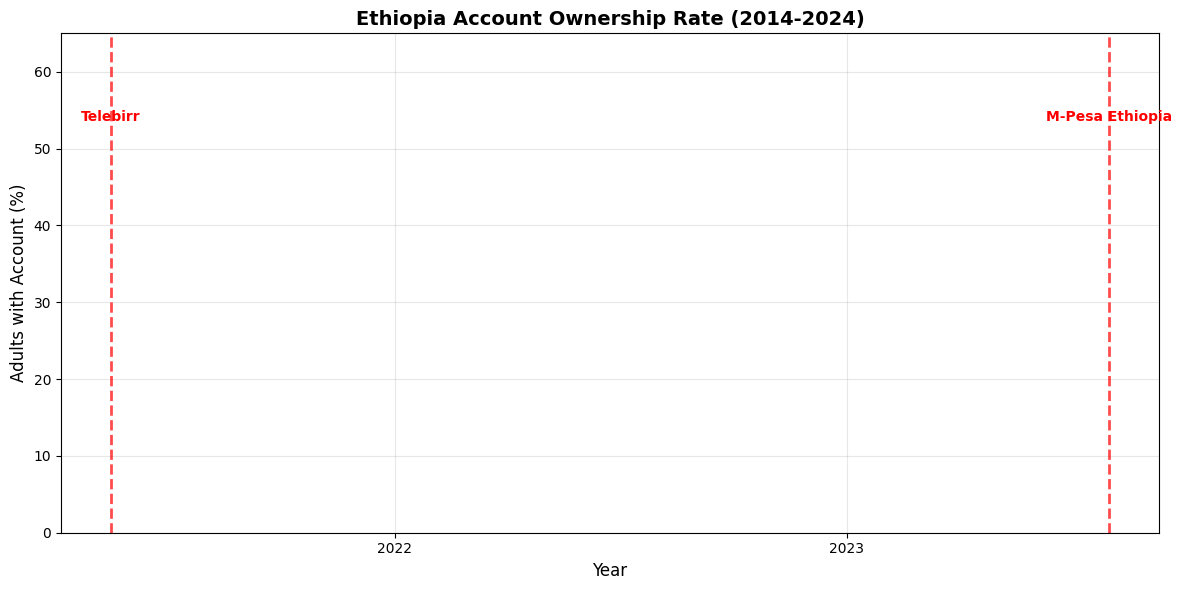

In [56]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# 1. RELOAD and force date parsing
df = pd.read_csv('../data/processed/ethiopia_fi_initial_save.csv')
df['observation_date'] = pd.to_datetime(df['observation_date'])

# 2. Filter to ONLY the National Account Ownership (no gender splits)
ownership = df[
    (df['record_type'] == 'observation') & 
    (df['indicator'] == 'Account Ownership Rate') & 
    (df['gender'].isna())  # This removes Male/Female splits
].sort_values('observation_date')

print("--- Data to be plotted ---")
print(ownership[['observation_date', 'value_numeric']])

# 3. Create the plot
fig, ax = plt.subplots(figsize=(12, 6))

# Convert dates to numbers (this ALWAYS works)
x_vals = mdates.date2num(ownership['observation_date'])
y_vals = ownership['value_numeric']

# Plot the line
ax.plot(x_vals, y_vals, marker='o', linestyle='-', linewidth=3, markersize=10, color='#2c3e50')

# Add labels on the points
for i, row in ownership.iterrows():
    ax.annotate(f"{row['value_numeric']:.0f}%", 
                xy=(mdates.date2num(row['observation_date']), row['value_numeric']),
                xytext=(0, 10), textcoords='offset points', ha='center', fontweight='bold')

# 4. Format the x-axis to show YEARS (not numbers)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator())

# 5. Add Event Lines
events = df[df['record_type'] == 'event']
important_events = events[events['indicator'].isin(['Telebirr Launch', 'M-Pesa Ethiopia Launch'])]

for _, event in important_events.iterrows():
    event_date = pd.to_datetime(event['observation_date'])
    event_x = mdates.date2num(event_date)  # Convert to number
    ax.axvline(x=event_x, color='red', linestyle='--', alpha=0.7, linewidth=2)
    ax.text(event_x, 55, event['indicator'].replace(' Launch',''), 
            rotation=0, fontsize=10, color='red', ha='center', va='top', fontweight='bold')

# 6. Final polish
ax.set_title('Ethiopia Account Ownership Rate (2014-2024)', fontsize=14, fontweight='bold')
ax.set_ylabel('Adults with Account (%)', fontsize=12)
ax.set_xlabel('Year', fontsize=12)
ax.grid(alpha=0.3)
ax.set_ylim(0, 65)

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Reload data
df = pd.read_csv('../data/processed/ethiopia_fi_initial_save.csv.csv')
df['observation_date'] = pd.to_datetime(df['observation_date'])

# Filter Account Ownership (national only)
ownership = df[
    (df['record_type'] == 'observation') & 
    (df['indicator'] == 'Account Ownership Rate') & 
    (df['gender'].isna()) &
    (df['location'].isna())
].sort_values('observation_date')

# Check if we have data
print("--- FOUND DATA ---")
print(ownership[['observation_date', 'value_numeric']])

# ---------- PLOT USING NUMERIC YEARS ----------
# Convert dates to simple numbers (year only)
years = ownership['observation_date'].dt.year
values = ownership['value_numeric']

# Create the plot
fig, ax = plt.subplots(figsize=(10, 5))

# Plot the data
ax.plot(years, values, marker='o', linestyle='-', linewidth=3, markersize=10, color='blue')

# Add labels on points
for i, row in ownership.iterrows():
    ax.annotate(f"{row['value_numeric']:.0f}%", 
                xy=(row['observation_date'].year, row['value_numeric']),
                xytext=(0, 10), textcoords='offset points', ha='center', fontweight='bold')

# Add event lines (Telebirr 2021, M-Pesa 2023)
events = df[df['record_type'] == 'event']
important_events = events[events['indicator'].isin(['Telebirr Launch', 'M-Pesa Ethiopia Launch'])]

for _, event in important_events.iterrows():
    event_year = pd.to_datetime(event['observation_date']).year
    ax.axvline(x=event_year, color='red', linestyle='--', alpha=0.7, linewidth=2)
    ax.text(event_year, 55, event['indicator'].replace(' Launch',''), 
            rotation=0, fontsize=10, color='red', ha='center', va='top', fontweight='bold')

# Labels
ax.set_title('Ethiopia Account Ownership Rate (2014-2024)', fontsize=14, fontweight='bold')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Adults with Account (%)', fontsize=12)
ax.set_ylim(0, 65)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print the data for your report
print("\n--- HISTORICAL DATA SUMMARY ---")
print(ownership[['observation_date', 'value_numeric']].to_string(index=False))

FileNotFoundError: [Errno 2] No such file or directory: '../data/processed/ethiopia_fi_enriched.csv'